<h1 style="text-align: center; color: darkblue;">Analysis</h1>

### 📑 <font color='blue'> Table of Contents </font>
1. [Introduction](#1)
2. [Setup](#2)
3. [Helper Functions](#3)
4. [Models](#4) <br>
    4.1. [Tree](#4.1) <br>
    4.2. [Neural Network](#4.2) <br>
5. [Comparison](#5)
6. [Conclusions](#6)

## <a id="1" style="color: darkred; text-decoration: none;">1. Introduction</a>


This notebook focuses on a detailed analysis of the best models obtained for each model type in the traffic classification task.
The goal is to better understand how each model makes its predictions and to compare their behavior and interpretability.

We start by analyzing the best-performing model of each family (e.g., tree-based models and neural networks) individually.
For tree-based models, we explore feature importance to identify which variables most influence the predictions.
For neural networks, we employ SHAP values to visualize and interpret feature contributions at a deeper level.

Finally, we perform a side-by-side comparison of the models, summarizing their performance and interpretability insights to highlight their respective strengths and limitations.


## <a id="2" style="color: darkred; text-decoration: none;">2. Setup </a>

In [116]:
import mlflow
import pandas as pd
from mlflow.tracking import MlflowClient
from pathlib import Path
import matplotlib.pyplot as plt
import json
import numpy as np
import time

import os, sys
import torch

In [42]:
print(Path().resolve().parent)

/home/marcos/Escritorio/AI-prod/AI-Driven-Network-Security


In [34]:
mlflow_path = Path().resolve().parent / "mlflow.db"
mlflow.set_tracking_uri(f"sqlite:///{mlflow_path}")

In [133]:
EXPERIMENT_NAME = "network_security"
N_RUNS = 100 # to meeasure inference time

## <a id="3" style="color: darkred; text-decoration: none;">3. Helper Functions </a>

In [35]:
def select_best_model(experiment_name, metric="f1", model_type='tree', data_version="v1"):
    client = MlflowClient()
    experiment = client.get_experiment_by_name(experiment_name)
    if experiment is None:
        raise ValueError(f"Experiment '{experiment_name}' not found.")

    # Build filter
    filter_str = f"run_name = 'Tuning' AND tags.data_version = '{data_version}'"
    if model_type:
        filter_str += f" AND tags.model_type = '{model_type}'"

    # Search runs
    runs = client.search_runs(
        experiment_ids=[experiment.experiment_id],
        filter_string=filter_str,
        order_by=[f"metrics.{metric} DESC"],
    )

    if not runs:
        raise ValueError(f"No runs found for model_type='{model_type}' and data_version='{data_version}'.")

    # Take best run
    best_run = runs[0]
    run_id = best_run.info.run_id
    
    return best_run

## <a id="4" style="color: darkred; text-decoration: none;"> 4. Models </a>

### <a id="4.1" style="color: darkorange; text-decoration: none;"> 4.1. Tree </a>

In [80]:
best_tree_run = select_best_model(EXPERIMENT_NAME, model_type='tree')

In [69]:
# Get metrics and params
metrics = best_tree_run.data.metrics
params = best_tree_run.data.params


# Converto to dataframe
df_params_tree = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df_metrics_tree = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

df_params_tree

,param,value
0,balance_factor,0.2
1,val_size,0.2
2,train_shape,"(150434, 78)"
3,val_shape,"(15461, 78)"
4,criterion,gini
5,max_depth,6
6,min_samples_split,9


In [70]:
df_metrics_tree

,metric,value
0,accuracy,0.938232
1,precision,0.980126
2,recall,0.938232
3,f1,0.956442


**Feature importance**

In [100]:
# best tree run id
best_tree_run_id = best_tree_run.info.run_id

# Load the model
tree_model = mlflow.sklearn.load_model(f"runs:/{best_tree_run_id}/model")

In [101]:
print(tree_model)

DecisionTreeClassifier(max_depth=6, min_samples_split=9, random_state=42)


**Inference Time**

In [110]:
def measure_inference_time_tree(model, n_features, n_samples=1, n_runs=100):
    times = []
    for _ in range(n_runs):
        X_sample = np.random.rand(n_samples, n_features)
        start = time.perf_counter()
        _ = model.predict(X_sample)
        end = time.perf_counter()
        times.append((end - start) / n_samples)  # per-sample latency
    return np.mean(times), np.std(times)

n_features = 78
mean_t, std_t = measure_inference_time_tree(tree_model, n_features)
print(f"Tree avg inference time: {mean_t*1000:.3f} ms ± {std_t*1000:.3f} ms")

Tree avg inference time: 0.315 ms ± 0.247 ms


In [113]:
# append inference time as new row
df_metrics_tree.loc[len(df)] = ['inference_time (s)', mean_t]

In [114]:
df_metrics_tree

,metric,value
0,accuracy,0.938232
1,precision,0.980126
2,recall,0.938232
3,f1,0.956442
4,inference_time (s),0.000315


### <a id="4.2" style="color: darkorange; text-decoration: none;"> 4.2. Neural Network </a>

In [132]:
best_nn_run = select_best_model(EXPERIMENT_NAME, model_type='nn')

In [78]:
# Get metrics and params
metrics = best_nn_run.data.metrics
params = best_nn_run.data.params


# Converto to dataframe
df_params_nn = pd.DataFrame({
    "param": list(params.keys()),
    "value": list(params.values())
})


df_metrics_nn = pd.DataFrame({
    "metric": list(metrics.keys()),
    "value": list(metrics.values())
})

df_params_nn

,param,value
0,balance_factor,0.2
1,val_size,0.2
2,train_shape,"(150434, 78)"
3,val_shape,"(15461, 78)"
4,scaler_type,standard
5,lr,0.0003138595960329352
6,final_lr,0.0003138595960329352
7,hidden1,256
8,hidden2,32
9,batch_size,32


In [79]:
df_metrics_nn

,metric,value
0,accuracy,0.957441
1,precision,0.973840
2,recall,0.957441
3,f1,0.963673


In [115]:
# Load model
#import src
sys.path.append(os.path.abspath(".."))  # if notebook is inside /notebooks

import mlflow.pytorch


best_nn_run_id = best_nn_run.info.run_id


artifact_paths = {
    "preprocessing": "preprocessing",       # folder under artifacts
    "plots": "plots",                        # folder under artifacts
    "model": "model"                         # model artifact path
}

# --------------------------
model_uri = f"runs:/{best_nn_run_id}/{artifact_paths['model']}"
model = mlflow.pytorch.load_model(model_uri)
print("TensorFlow model loaded successfully!")


print(model)

2025/11/07 16:54:28 WARNING mlflow.pytorch: Stored model version '2.8.0+cpu' does not match installed PyTorch version '2.3.1+cpu'


TensorFlow model loaded successfully!
NNModel(
  (model): Sequential(
    (0): Linear(in_features=78, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=10, bias=True)
  )
)


**Inference time**

In [117]:
def measure_inference_time(model, sample_input, n_runs=100, device='cpu'):
    model.eval()
    model.to(device)
    sample_input = sample_input.to(device)

    # Warm-up (to stabilize GPU/CPU performance)
    for _ in range(10):
        _ = model(sample_input)

    torch.cuda.synchronize(device) if device.startswith('cuda') else None

    times = []
    with torch.no_grad():
        for _ in range(n_runs):
            start = time.perf_counter()
            _ = model(sample_input)
            torch.cuda.synchronize(device) if device.startswith('cuda') else None
            end = time.perf_counter()
            times.append(end - start)

    mean_time = np.mean(times)
    std_time = np.std(times)
    return mean_time, std_time


In [119]:
sample_input = torch.randn(1, 78)  # adjust to your model’s input shape
mean_nn, std_nn = measure_inference_time(model, sample_input, n_runs=100, device='cpu')
print(f"Avg inference time: {mean_nn*1000:.3f} ms ± {std_nn*1000:.3f} ms")

Avg inference time: 0.239 ms ± 0.625 ms


In [120]:
# append inference time as new row
df_metrics_nn.loc[len(df)] = ['inference_time (s)', mean_nn]

In [121]:
df_metrics_nn

,metric,value
0,accuracy,0.957441
1,precision,0.973840
2,recall,0.957441
3,f1,0.963673
4,inference_time (s),0.000239


## <a id="5" style="color: darkred; text-decoration: none;"> 5. Comparison </a>


In [131]:
# Give names to the model types
df1 = df_metrics_tree.rename(columns={'value': 'Tree'})
df2 = df_metrics_nn.rename(columns={'value': 'Neural Network'})

dfs = [df1, df2] 
df = dfs[0]
for d in dfs[1:]:
    comparison = comparison.merge(df, on='metric')
    

comparison

,metric,Tree_x,Neural Network,Tree_y
0,accuracy,0.938232,0.957441,0.938232
1,precision,0.980126,0.973840,0.980126
2,recall,0.938232,0.957441,0.938232
3,f1,0.956442,0.963673,0.956442
4,inference_time (s),0.000315,0.000239,0.000315


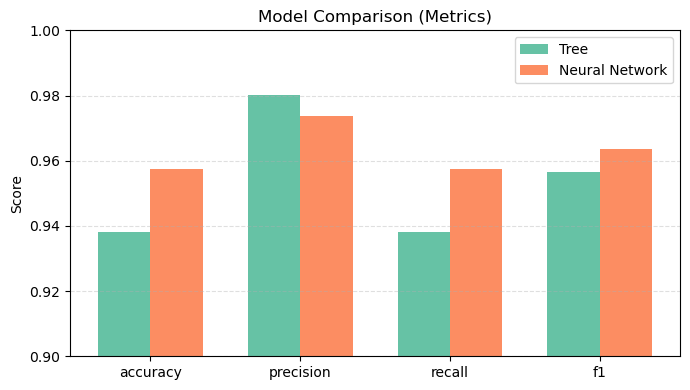

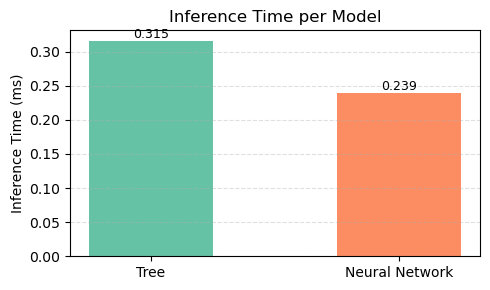

In [128]:
df = comparison

# Split metrics vs timing
df_metrics = df[df['metric'] != 'inference_time (s)']
df_time = df[df['metric'] == 'inference_time (s)']

# Use consistent color palette
models = df.columns[1:]
colors = sns.color_palette("Set2", n_colors=len(models))
color_map = dict(zip(models, colors))

# --- METRICS PLOT ---
df_melted = df_metrics.melt(id_vars='metric', var_name='Model', value_name='Score')

plt.figure(figsize=(7,4))
width = 0.35

for i, model in enumerate(models):
    subset = df_melted[df_melted['Model'] == model]
    plt.bar(
        [x + i*width for x in range(len(subset))],
        subset['Score'],
        width=width,
        label=model,
        color=color_map[model]
    )

plt.xticks([r + width/2 for r in range(len(df_metrics))], df_metrics['metric'])
plt.ylabel("Score")
plt.title("Model Comparison (Metrics)")
plt.ylim(0.9, 1.0)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

# --- INFERENCE TIME PLOT ---
df_time_melted = df_time.melt(id_vars='metric', var_name='Model', value_name='Time (s)')

plt.figure(figsize=(5,3))
bars = plt.bar(
    df_time_melted['Model'],
    df_time_melted['Time (s)'] * 1000,
    color=[color_map[m] for m in df_time_melted['Model']],
    width=0.5
)

# Add labels
for bar in bars:
    plt.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height(),
        f"{bar.get_height():.3f}",
        ha='center', va='bottom', fontsize=9
    )

plt.ylabel("Inference Time (ms)")
plt.title("Inference Time per Model")
plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


## <a id="6" style="color: darkred; text-decoration: none;"> 6. Conclusions </a>

In [ ]:
# for now i did not include preprocessing time!!!!!!!